In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import znet without installing it
sys.path.append(os.path.abspath('..'))

import torch
from znet import *
from torch.func import grad_and_value, vmap, grad

# import thermograph.nodes as tn
# import matplotlib.pyplot as plt
# import numpy as np

print("znet imported successfully")

znet imported successfully


In [2]:
RT = 8.314*300

In [3]:
mu1 = TPowNode(SignalNode(1),-1)
mu2 = TPowNode(SignalNode(2),-1)
RT0 = ConstantNode(RT)

In [4]:
x = torch.tensor([293,-1000,1000], dtype=torch.float32)

In [5]:
mu1A = TProdNode([RT0, mu1])
mu2A = mu2
mu1B = mu1
mu2B = TProdNode([RT0, mu2])

In [6]:
phaseA = FactorNode(torch.tensor([[1,0],[0,1]]), [mu1A, mu2A], beta_factor = 8.314)
phaseB = FactorNode(torch.tensor([[1,0],[0,1]]), [mu1B, mu2B], beta_factor = 8.314)
system = FactorNode(torch.tensor([[1,0],[0,1]]), [phaseA, phaseB], beta_factor = 1e-8*8.314)

In [51]:
def partial_legendrea(fcn, x, transform_indicies):
    """
    Evaluates phaseA(x) and applies F = E - sum(y_i * x_i)
    for the specified indices.
    """
    # grad_and_value returns the gradients and the scalar output in one pass
    grads, energy = grad_and_value(fcn)(x)
    
    # Extract the conjugate variables (y = dE/dx) for the target indices
    y_partial = grads[transform_indicies]
    x_partial = x[transform_indicies]
    
    # The Legendre Transform using a dot product
    transformed_energy = energy - torch.dot(y_partial, x_partial)

    new_x_stack = x.clone()
    #new_x_stack = torch.where(transform_indicies, grads, x)
    new_x_stack[transform_indicies] = grads[transform_indicies]

    
    return new_x_stack, transformed_energy

In [59]:
ft = partial_legendrea(phaseA, x, [1,2])
ftb = vmap(ft)

In [60]:
input_tensor, state_order = build_input_tensor(
    {
        "T": torch.tensor(293.15),
        "mu_1": torch.linspace(-10*RT, 10*RT, steps=50),
        "mu_2": torch.linspace(10*RT, -10*RT, steps=50),
    },
    mode ="matched",
)

In [64]:
phaseAb = vmap(phaseA)
phaseBb = vmap(phaseB)
systemb = vmap(system)
phaseAb(input_tensor)

tensor([27436.1973, 26418.1582, 25400.1172, 24382.0762, 23364.0352, 22345.9961,
        21327.9531, 20309.9141, 19291.8750, 18273.8340, 17255.7969, 16237.7607,
        15219.7354, 14201.7285, 13183.7656, 12165.9004, 11148.2686, 10131.1709,
         9115.3018,  8102.2598,  7095.7070,  6103.9512,  5145.4570,  4259.4106,
         3520.9556,  3046.5625,  2952.5161,  3266.9092,  3902.6919,  4734.2866,
         5666.8091,  6646.8081,  7648.1631,  8658.9307,  9673.8105, 10690.4805,
        11707.9248, 12725.7070, 13743.6367, 14761.6289, 15779.6494, 16797.6816,
        17815.7168, 18833.7539, 19851.7969, 20869.8359, 21887.8789, 22905.9180,
        23923.9590, 24942.0000], grad_fn=<MulBackward0>)

In [66]:
ftb(input_tensor)

TypeError: 'tuple' object is not callable

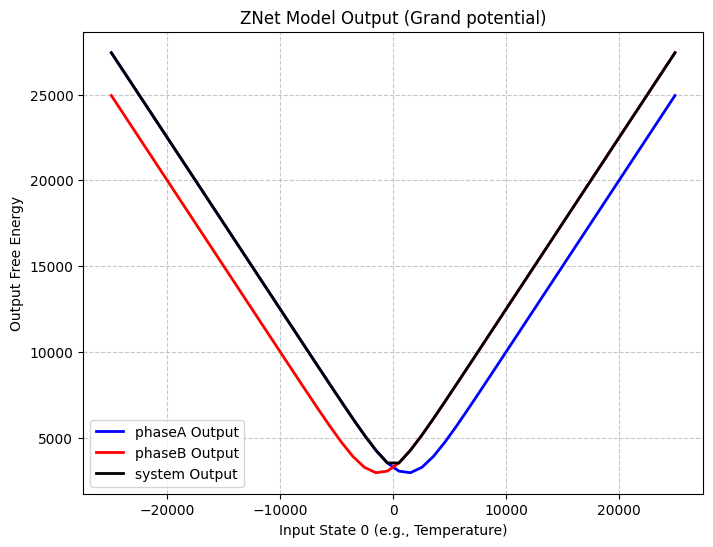

In [9]:
import matplotlib.pyplot as plt


# 3. Plot
plt.figure(figsize=(8, 6))

y_vals = phaseAb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='phaseA Output', color='blue', linewidth=2)

y_vals = phaseBb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='phaseB Output', color='red', linewidth=2)

y_vals = systemb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='system Output', color='black', linewidth=2)

plt.title("ZNet Model Output (Grand potential)")
plt.xlabel("Input State 0 (e.g., Temperature)")
plt.ylabel("Output Free Energy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [10]:
mu_a_axis = input_tensor[:, 0].detach().numpy()
mu_b_axis = input_tensor[:, 1].detach().numpy()

phase_a_vals = phase_a_output.detach().numpy().flatten()
phase_b_vals = phase_b_output.detach().numpy().flatten()
system_vals = system_output.detach().numpy().flatten()

plt.figure(figsize=(9, 5))
plt.plot(mu_a_axis, phase_a_vals, label=r'$\Omega_A$', linewidth=2, marker='o', markersize=3)
plt.plot(mu_a_axis, phase_b_vals, label=r'$\Omega_B$', linewidth=2, marker='s', markersize=3)
plt.plot(mu_a_axis, system_vals, label=r'$\Omega_{sys}$', linewidth=2, marker='^', markersize=3)
plt.xlabel(r'$\mu_A$')
plt.ylabel(r'Grand Potential $\Omega$')
plt.title(r'$\Omega_A$, $\Omega_B$, and $\Omega_{sys}$ vs $\mu_A$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'phase_a_output' is not defined

In [ ]:
fa = (input_tensor*phase_a_grad).sum(dim=-1).unsqueeze(-1)-phase_a_output
fb = (input_tensor*phase_b_grad).sum(dim=-1).unsqueeze(-1)-phase_b_output
fsys = (input_tensor*system_grad).sum(dim=-1).unsqueeze(-1)-system_output

In [ ]:
xa = (phase_a_grad[..., 0]-phase_a_grad[..., 1] ).detach().numpy().flatten()
fa_plot = fa.detach().numpy().flatten()

xb = (phase_b_grad[..., 0]-phase_b_grad[..., 1] ).detach().numpy().flatten()
fb_plot = fb.detach().numpy().flatten()

xsys = (system_grad[..., 0]-system_grad[..., 1] ).detach().numpy().flatten()
fsys_plot = fsys.detach().numpy().flatten()


plt.figure(figsize=(8, 5))
plt.plot(xa, fa_plot, marker='o', linewidth=2)
plt.plot(xb, fb_plot, marker='s', linewidth=2)  
plt.plot(xsys, fsys_plot, marker='^', linewidth=2)
plt.xlabel(r'$\partial \Omega_A / \partial \mu_A - \partial \Omega_A / \partial \mu_B$')
plt.ylabel(r'$f = \mu \cdot \nabla\Omega - \Omega$')
plt.title(r'$f$ vs $\nabla\Omega_A[0] - \nabla\Omega_A[1]$')
plt.legend(['Phase A', 'Phase B', 'System'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# phase_a_grad shape: (10, 10, 2) — two derivatives per point
# f shape: (10, 10, 1)

grad_muA = phase_a_grad[..., 0].detach().numpy().flatten()  # d(phase_a)/d(mu_A)
grad_muB = phase_a_grad[..., 1].detach().numpy().flatten()  # d(phase_a)/d(mu_B)
f_vals   = f.detach().numpy().flatten()

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(grad_muA, grad_muB, f_vals,
                c=f_vals, cmap='viridis', s=20, alpha=0.8)

ax.set_xlabel(r'$\partial \Omega_A / \partial \mu_A$  ($N_A$)')
ax.set_ylabel(r'$\partial \Omega_A / \partial \mu_B$  ($N_B$)')
ax.set_zlabel(r'$f = \mu \cdot \nabla\Omega - \Omega$')
ax.set_title(r'$f$ vs gradients of $\Omega_A$')
fig.colorbar(sc, ax=ax, shrink=0.5, label='f value')

plt.tight_layout()
plt.show()

In [ ]:
omega_a_vals = phase_a(inputs).detach().numpy().flatten()
mu_a_axis = inputs["mu_A"].detach().numpy().flatten()


helmholtz_a_vals, N_a_vals = phase_a.to_Helmholtz(inputs)
# Extract the particle number for the key 'mu_A'
N_a_axis = N_a_vals['mu_A'].detach().numpy().flatten()
helmholtz_a_vals = helmholtz_a_vals.detach().numpy().flatten()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Grand Potential vs Chemical Potential
ax1.plot(mu_a_axis, omega_a_vals, 'b-', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel(r'Chemical Potential $\mu_A$ (eV)')
ax1.set_ylabel(r'Grand Potential $\Omega_A$ (eV)')
ax1.set_title(r'$\Omega_A$ vs $\mu_A$')
ax1.grid(True, alpha=0.3)

# Plot 2: Helmholtz Free Energy vs Particle Number
if len(N_a_axis) > 0:
    ax2.plot(N_a_axis, helmholtz_a_vals, 'r-', linewidth=2, marker='s', markersize=4)
    ax2.set_xlabel(r'Expected Particle Number $\langle N_A \rangle$')
    ax2.set_ylabel(r'Helmholtz Free Energy $F_A$ (eV)')
    ax2.set_title(r'$F_A$ vs $N_A$')
    ax2.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

In [ ]:
omega_a_vals = phase_a(inputs).detach().numpy().flatten()
omega_b_vals = phase_b(inputs).detach().numpy().flatten()
mu_a_axis = inputs["mu_A"].detach().numpy().flatten()

plt.figure(figsize=(8, 5))
plt.plot(mu_a_axis, omega_a_vals, label=r'$\Omega_A$', linewidth=2)
plt.plot(mu_a_axis, omega_b_vals, label=r'$\Omega_B$', linewidth=2)
plt.xlabel(r'Chemical Potential $\mu_A$ (eV)')
plt.ylabel(r'Grand Potential $\Omega$ (eV)')
plt.title(r'$\Omega_A$ and $\Omega_B$ vs $\mu_A$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ideal_mixed = MixingNode([StackNode([phase_a, phase_b])], scale=1e-5)
omega = ideal_mixed

In [ ]:
import matplotlib.pyplot as plt
# 5. Visualization
Helmholtz_F, N_counts = omega.to_Helmholtz(inputs)
Omega = omega(inputs)

# Flatten() ensures everything is a 1D array for plotting
mu_axis = inputs['mu_A'].detach().numpy().flatten()
y_omega = Omega.detach().numpy().flatten()
y_helmholtz = Helmholtz_F.detach().numpy().flatten()
y_NA = N_counts['mu_A'].detach().numpy().flatten()

# Note: We do not simplify sorting here because F(N) needs N to be the x-axis, 
# and mu might not be monotonic with N in complex systems (though here it is).
sort_idx = mu_axis.argsort()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Grand Potential vs Chemical Potential (Natural Variables)
ax1.set_xlabel(r'Chemical Potential $\mu_A$')
ax1.set_ylabel(r'Grand Potential $\Omega$', color='tab:red')
ax1.plot(mu_axis[sort_idx], y_omega[sort_idx], 'r--', linewidth=2, label=r'$\Omega(\mu)$')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title(r'Grand Canonical Ensemble ($\mu \to \Omega$)')

# Plot 2: Helmholtz Free Energy vs Particle Number (Conjugate Variables)
# Ideally F is plotted against its natural variable N_A
# Sort by N_A for a clean line
sort_N = y_NA.argsort()

ax2.set_xlabel(r'Particle Fraction $N_A$')
ax2.set_ylabel(r'Helmholtz Free Energy $F$', color='tab:green')
ax2.plot(y_NA[sort_N], y_helmholtz[sort_N], 'g-', linewidth=3, label=r'$F(N)$', marker='o')
ax2.legend(loc='upper center')
ax2.grid(True, alpha=0.3)
ax2.set_title(r'Canonical Ensemble ($N \to F$)')

plt.tight_layout()
plt.show()